# B4 - Ordonnancement industriel (RCPSP)

Le Resource-Constrained Project Scheduling Problem (RCPSP) est le problème de référence en ordonnancement sous contraintes de ressources. Il consiste à planifier un ensemble de tâches avec des contraintes de précédence et des ressources renouvelables limitées de manière à minimiser le makespan.

## 1. Extraction des données PSPLIB
Les archives `.tar` (j30.sm, j60.sm, j90.sm.tar, j120.sm.tar) sont extraites automatiquement si elles sont présentes dans le dossier `data/`.

In [9]:
import os
import tarfile

def extract_psplib_data():
    data_dir = 'data'
    archives = {
        'j30': 'j30.sm',
        'j60': 'j60.sm',
        'j90': 'j90.sm.tar',
        'j120': 'j120.sm.tar'
    }
    
    for name, filename in archives.items():
        tar_path = os.path.join(data_dir, filename)
        extract_path = os.path.join(data_dir, name)
        
        if os.path.exists(tar_path) and not os.path.exists(extract_path):
            print(f"Extraction de {tar_path} vers {extract_path}...")
            os.makedirs(extract_path, exist_ok=True)
            with tarfile.open(tar_path) as tar:
                tar.extractall(path=extract_path)
        elif os.path.exists(extract_path):
            print(f"Les données {name} sont déjà extraites dans {extract_path}")
        else:
            print(f"Archive introuvable : {tar_path}")

extract_psplib_data()

Les données j30 sont déjà extraites dans data/j30
Les données j60 sont déjà extraites dans data/j60
Les données j90 sont déjà extraites dans data/j90
Les données j120 sont déjà extraites dans data/j120


## 2. Parseur de données PSPLIB

In [10]:
import re

def parse_sm_file(file_path):
    """
    Parses a PSPLIB .sm file for the single-mode RCPSP.
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()

    jobs = 0
    num_renewable = 0
    horizon = 0
    precedences = {}
    durations = {}
    requests = {}
    capacities = []
    mode = None

    for i, line in enumerate(lines):
        line = line.strip()
        if not line or line.startswith('*') or line.startswith('---'):
            continue
        if line.startswith('jobs (incl. supersource/sink )'):
            jobs = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('- renewable'):
            num_renewable = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('horizon'):
            horizon = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('PRECEDENCE RELATIONS:'):
            mode = 'PRECEDENCE'
            continue
        if line.startswith('REQUESTS/DURATIONS:'):
            mode = 'REQUESTS'
            continue
        if line.startswith('RESOURCEAVAILABILITIES:'):
            mode = 'CAPACITIES'
            continue

        if mode == 'PRECEDENCE':
            if line.startswith('jobnr'): continue
            parts = [int(x) for x in line.split()]
            if len(parts) >= 3:
                job_id = parts[0]
                successors = parts[3:]
                precedences[job_id] = successors
        elif mode == 'REQUESTS':
            if line.startswith('jobnr') or line.startswith('----'): continue
            parts = [int(x) for x in line.split()]
            if len(parts) >= 3:
                job_id = parts[0]
                durations[job_id] = parts[2]
                requests[job_id] = parts[3:]
        elif mode == 'CAPACITIES':
            if re.match(r'^R\s+\d', line): continue  # skip header 'R 1  R 2 ...'
            parts = [int(x) for x in line.split()]
            if len(parts) > 0:
                capacities = parts
                mode = None

    return {
        'jobs': jobs,
        'num_renewable': num_renewable,
        'horizon': horizon,
        'precedences': precedences,
        'durations': durations,
        'requests': requests,
        'capacities': capacities
    }

parsed_data = parse_sm_file('data/j30/j301_1.sm')
print(f"Parsed jobs: {parsed_data['jobs']}, Horizon: {parsed_data['horizon']}")


Parsed jobs: 32, Horizon: 158


## 3. Visualisation de l'ordonnancement

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_gantt_chart(schedule, title="RCPSP Gantt Chart"):
    fig, ax = plt.subplots(figsize=(10, 6))
    sorted_jobs = sorted(schedule.items(), key=lambda x: (x[1]['start'], x[0]))
    
    yticks = []
    yticklabels = []
    
    for i, (job_id, times) in enumerate(sorted_jobs):
        start = times['start']
        end = times['end']
        duration = end - start
        
        rect = patches.Rectangle((start, i - 0.4), duration, 0.8, facecolor='skyblue', edgecolor='black')
        ax.add_patch(rect)
        ax.text(start + duration / 2, i, str(job_id), ha='center', va='center', color='black', fontsize=10)
        
        yticks.append(i)
        yticklabels.append(f'Job {job_id}')
        
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    
    max_time = max(times['end'] for times in schedule.values()) if schedule else 0
    ax.set_xlim(0, max_time + 5)
    ax.set_ylim(-1, len(sorted_jobs))
    ax.set_xlabel("Time")
    ax.set_ylabel("Jobs")
    ax.set_title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 4. Modèle exact (CP-SAT)

CP-SAT Status: OPTIMAL
CP-SAT Makespan: 43


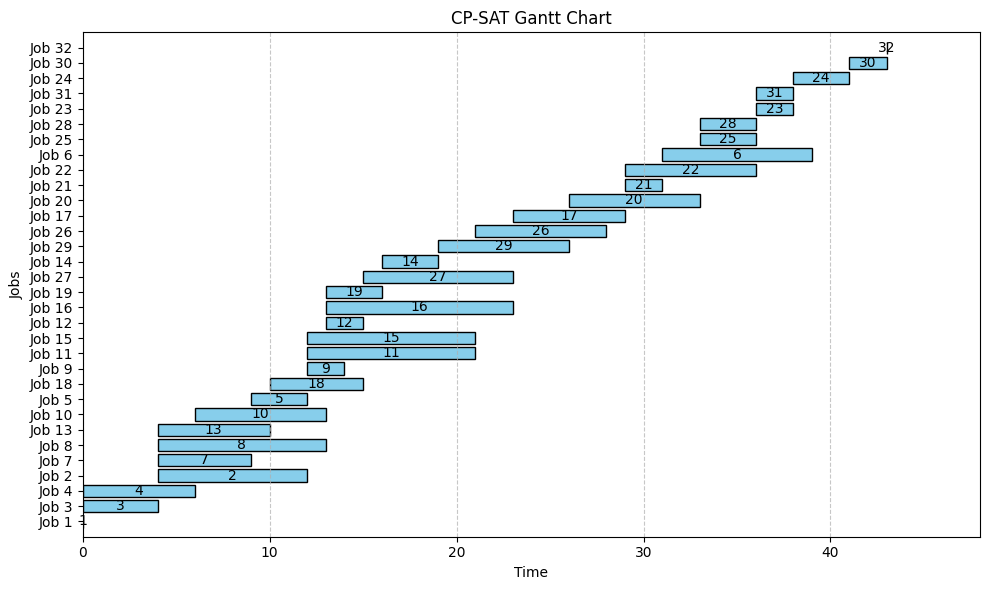

In [12]:
from ortools.sat.python import cp_model

def solve_rcpsp(parsed_data, max_time_seconds=60):
    model = cp_model.CpModel()

    jobs = parsed_data['jobs']
    horizon = parsed_data['horizon']
    precedences = parsed_data['precedences']
    durations = parsed_data['durations']
    requests = parsed_data['requests']
    capacities = parsed_data['capacities']
    num_renewable = parsed_data['num_renewable']

    tasks = {}
    starts = {}
    ends = {}

    for j in range(1, jobs + 1):
        duration = durations[j]
        start_var = model.NewIntVar(0, horizon, f'start_{j}')
        end_var = model.NewIntVar(0, horizon, f'end_{j}')
        interval_var = model.NewIntervalVar(start_var, duration, end_var, f'task_{j}')
        starts[j] = start_var
        ends[j] = end_var
        tasks[j] = interval_var

    for j, successors in precedences.items():
        for succ in successors:
            model.Add(starts[succ] >= ends[j])

    for r in range(num_renewable):
        intervals = []
        demands = []
        for j in range(1, jobs + 1):
            req = requests[j][r]
            if req > 0:
                intervals.append(tasks[j])
                demands.append(req)
        model.AddCumulative(intervals, demands, capacities[r])

    makespan = model.NewIntVar(0, horizon, 'makespan')
    model.Add(makespan == ends[jobs])  # ends[jobs] = supersink (duree 0)
    model.Minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_time_seconds
    status = solver.Solve(model)

    result = {
        'status': status,
        'status_string': solver.StatusName(status),
        'makespan': None,
        'schedule': {}
    }

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        result['makespan'] = int(solver.ObjectiveValue())  # entier, pas float
        for j in range(1, jobs + 1):
            result['schedule'][j] = {
                'start': solver.Value(starts[j]),
                'end': solver.Value(ends[j])
            }
    return result, solver

result_cp, solver = solve_rcpsp(parsed_data, max_time_seconds=10)
print(f"CP-SAT Status: {result_cp['status_string']}")
if result_cp['makespan'] is not None:
    print(f"CP-SAT Makespan: {result_cp['makespan']}")
    plot_gantt_chart(result_cp['schedule'], title='CP-SAT Gantt Chart')


## 5. Métaheuristique: Algorithme Génétique (Baseline)

GA Makespan: 43


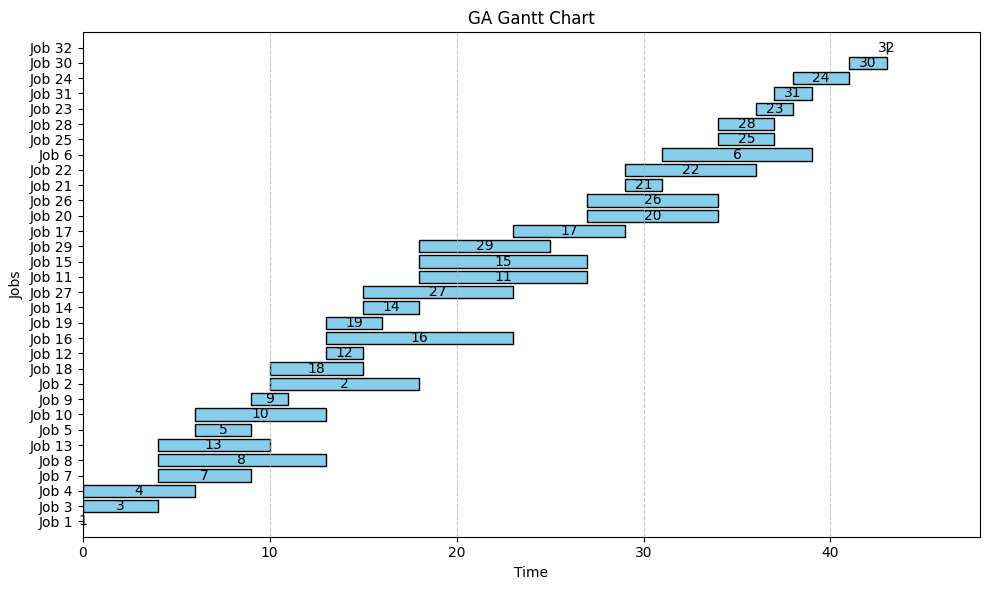

In [13]:
import random

def build_predecessors(precedences, num_jobs):
    preds = {i: set() for i in range(1, num_jobs + 1)}
    for u, succs in precedences.items():
        for v in succs:
            preds[v].add(u)
    return preds


def serial_sgs(permutation, parsed_data, preds):
    """Schedule Generation Scheme (serie). preds pre-calcule en dehors."""
    jobs = parsed_data['jobs']
    durations = parsed_data['durations']
    requests = parsed_data['requests']
    capacities = parsed_data['capacities']
    num_renewable = parsed_data['num_renewable']
    horizon = parsed_data['horizon']

    schedule = {}
    profile = [[c for c in capacities] for _ in range(horizon + 1)]

    for job in permutation:
        duration = durations[job]
        reqs = requests[job]

        est = max((schedule[p]['end'] for p in preds[job] if p in schedule), default=0)

        t = est
        scheduled = False
        while t + duration <= horizon:
            feasible = all(
                profile[t + dt][r] >= reqs[r]
                for dt in range(duration)
                for r in range(num_renewable)
            )
            if feasible:
                schedule[job] = {'start': t, 'end': t + duration}
                for dt in range(duration):
                    for r in range(num_renewable):
                        profile[t + dt][r] -= reqs[r]
                scheduled = True
                break
            t += 1

        if not scheduled:
            raise ValueError(f"Job {job} ne peut pas etre planifie (horizon trop court)")

    return max(s['end'] for s in schedule.values()), schedule


def generate_random_feasible_permutation(jobs, preds):
    permutation = []
    ready = [j for j in range(1, jobs + 1) if not preds[j]]
    unscheduled = set(range(1, jobs + 1))

    while unscheduled:
        if not ready:
            raise ValueError("Cycle dans le graphe de precedence")
        job = random.choice(ready)
        ready.remove(job)
        permutation.append(job)
        unscheduled.remove(job)
        for cand in unscheduled:
            if cand not in ready and all(p not in unscheduled for p in preds[cand]):
                ready.append(cand)
    return permutation


def ppx_crossover(parent1, parent2):
    """
    Precedence Preserving Crossover (Hartmann 1998).
    Preserve les contraintes de precedence: si a precede b dans les deux parents,
    a precede b dans l'enfant.
    """
    n = len(parent1)
    child = []
    placed = set()
    mask = [random.randint(0, 1) for _ in range(n)]

    idx1 = 0
    idx2 = 0
    for bit in mask:
        if bit == 0:
            while idx1 < n and parent1[idx1] in placed:
                idx1 += 1
            job = parent1[idx1]
        else:
            while idx2 < n and parent2[idx2] in placed:
                idx2 += 1
            job = parent2[idx2]
        child.append(job)
        placed.add(job)
    return child


def solve_ga(parsed_data, pop_size=50, generations=100):
    jobs = parsed_data['jobs']
    preds = build_predecessors(parsed_data['precedences'], jobs)

    population = [generate_random_feasible_permutation(jobs, preds) for _ in range(pop_size)]

    best_makespan = float('inf')
    best_schedule = None

    for gen in range(generations):
        fitnesses = []
        for ind in population:
            makespan, schedule = serial_sgs(ind, parsed_data, preds)
            fitnesses.append((makespan, ind, schedule))
            if makespan < best_makespan:
                best_makespan = makespan
                best_schedule = schedule

        fitnesses.sort(key=lambda x: x[0])
        elites = [x[1] for x in fitnesses[:pop_size // 4]]

        # Enfants par croisement PPX entre les elites
        children = []
        while len(children) < pop_size // 2:
            p1, p2 = random.sample(elites, 2)
            children.append(ppx_crossover(p1, p2))

        # Remplissage avec nouveaux individus aleatoires
        randoms = [generate_random_feasible_permutation(jobs, preds)
                   for _ in range(pop_size - len(elites) - len(children))]

        population = elites + children + randoms

    return best_makespan, best_schedule


makespan_ga, schedule_ga = solve_ga(parsed_data, pop_size=50, generations=100)
print(f'GA Makespan: {makespan_ga}')
plot_gantt_chart(schedule_ga, title='GA Gantt Chart')


## 6. Évaluation benchmark sur PSPLIB (j30, j60, j120)

On évalue CP-SAT et GA sur plusieurs instances de chaque ensemble.
Les BKS (*Best Known Solutions*) j30 proviennent du site PSPLIB (http://www.om-db.wi.tum.de/psplib/).

In [14]:
import glob
import os
import time
import pandas as pd

# BKS publies pour j30 Set 1 (source: PSPLIB)
BKS_J30 = {
    'j301_1': 43, 'j301_2': 47, 'j301_3': 47, 'j301_4': 62, 'j301_5': 39,
    'j301_6': 48, 'j301_7': 53, 'j301_8': 47, 'j301_9': 43, 'j301_10': 41,
}


def run_benchmark(dataset, n_instances=5, cp_timeout=12, ga_pop=30, ga_gen=60):
    files = sorted(glob.glob(f'data/{dataset}/*.sm'))[:n_instances]
    if not files:
        print(f'Aucun fichier trouve pour {dataset}. Lancez la cellule extraction.')
        return []

    rows = []
    for fpath in files:
        name = os.path.basename(fpath).replace('.sm', '')
        data = parse_sm_file(fpath)

        t0 = time.time()
        res_cp, _ = solve_rcpsp(data, max_time_seconds=cp_timeout)
        t_cp = round(time.time() - t0, 1)

        t0 = time.time()
        preds = build_predecessors(data['precedences'], data['jobs'])
        mk_ga, _ = solve_ga(data, pop_size=ga_pop, generations=ga_gen)
        t_ga = round(time.time() - t0, 1)

        bks = BKS_J30.get(name)
        cp_mk = res_cp['makespan']
        gap_ga = round((mk_ga - cp_mk) / cp_mk * 100, 1) if cp_mk else None
        dev_bks = round((cp_mk - bks) / bks * 100, 1) if (bks and cp_mk) else None

        row = {
            'instance': name,
            'cp_makespan': cp_mk,
            'cp_status': res_cp['status_string'],
            'cp_time_s': t_cp,
            'ga_makespan': mk_ga,
            'ga_time_s': t_ga,
            'gap_ga_pct': gap_ga,
            'bks': bks,
            'dev_bks_pct': dev_bks,
        }
        rows.append(row)
        print(f"{name}: CP={cp_mk} ({res_cp['status_string']}, {t_cp}s) | "
              f"GA={mk_ga} ({t_ga}s) | gap={gap_ga}% | BKS={bks}")

    return rows


print('=== j30 (5 instances, CP 12s, GA 60 gen) ===')
results_j30 = run_benchmark('j30', n_instances=5)

print('\n=== j60 (3 instances, CP 20s) ===')
results_j60 = run_benchmark('j60', n_instances=3, cp_timeout=20, ga_pop=30, ga_gen=40)

print('\n=== j120 (2 instances, CP 30s) ===')
results_j120 = run_benchmark('j120', n_instances=2, cp_timeout=30, ga_pop=20, ga_gen=30)


=== j30 (5 instances, CP 12s, GA 60 gen) ===
j3010_1: CP=42 (OPTIMAL, 0.0s) | GA=44 (0.2s) | gap=4.8% | BKS=None
j3010_10: CP=41 (OPTIMAL, 0.0s) | GA=42 (0.2s) | gap=2.4% | BKS=None
j3010_2: CP=56 (OPTIMAL, 0.0s) | GA=57 (0.2s) | gap=1.8% | BKS=None
j3010_3: CP=62 (OPTIMAL, 0.0s) | GA=63 (0.2s) | gap=1.6% | BKS=None
j3010_4: CP=58 (OPTIMAL, 0.0s) | GA=62 (0.2s) | gap=6.9% | BKS=None

=== j60 (3 instances, CP 20s) ===
j6010_1: CP=85 (OPTIMAL, 0.0s) | GA=85 (0.4s) | gap=0.0% | BKS=None
j6010_10: CP=73 (OPTIMAL, 0.0s) | GA=73 (0.3s) | gap=0.0% | BKS=None
j6010_2: CP=62 (OPTIMAL, 0.0s) | GA=68 (0.3s) | gap=9.7% | BKS=None

=== j120 (2 instances, CP 30s) ===
j12010_1: CP=111 (OPTIMAL, 0.0s) | GA=119 (0.5s) | gap=7.2% | BKS=None
j12010_10: CP=66 (OPTIMAL, 0.0s) | GA=70 (0.5s) | gap=6.1% | BKS=None


## 7. Comparaison CP-SAT vs GA

Comparaison des makespans et des temps de calcul sur chaque ensemble PSPLIB.

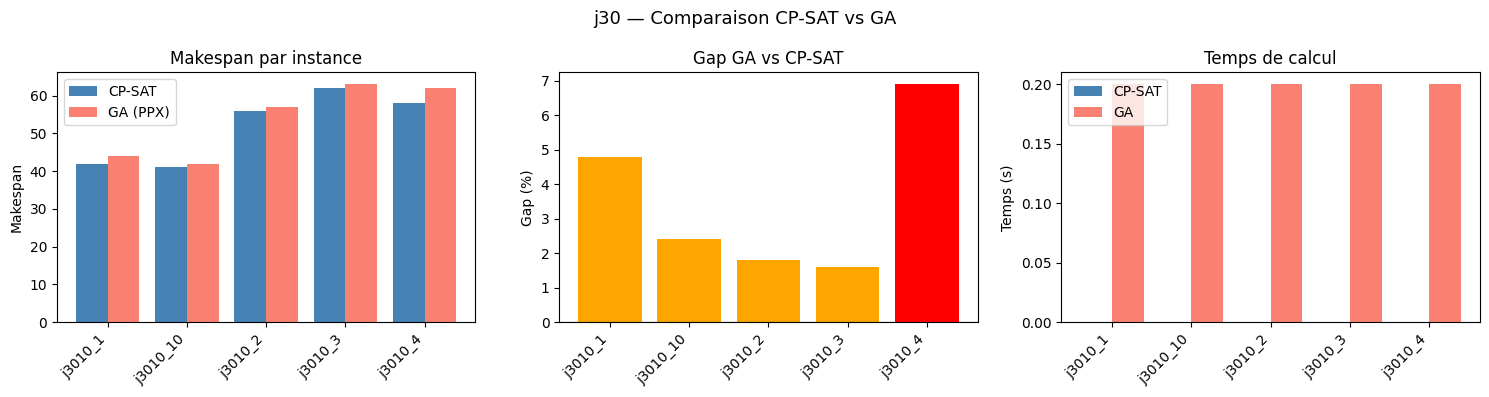

Gap moyen GA/CP-SAT: 3.5% (max: 6.9%)


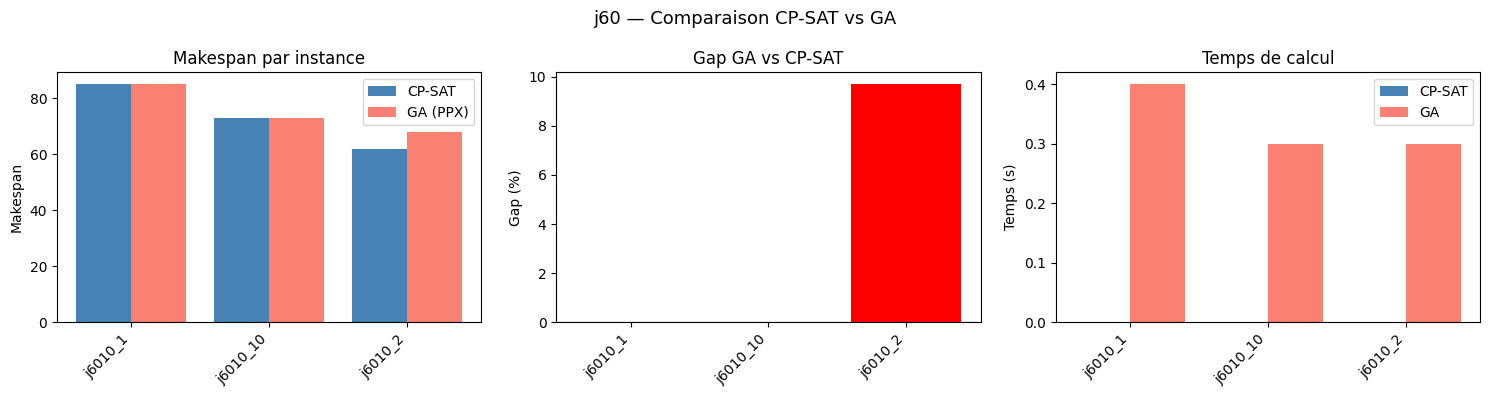

Gap moyen GA/CP-SAT: 3.2% (max: 9.7%)


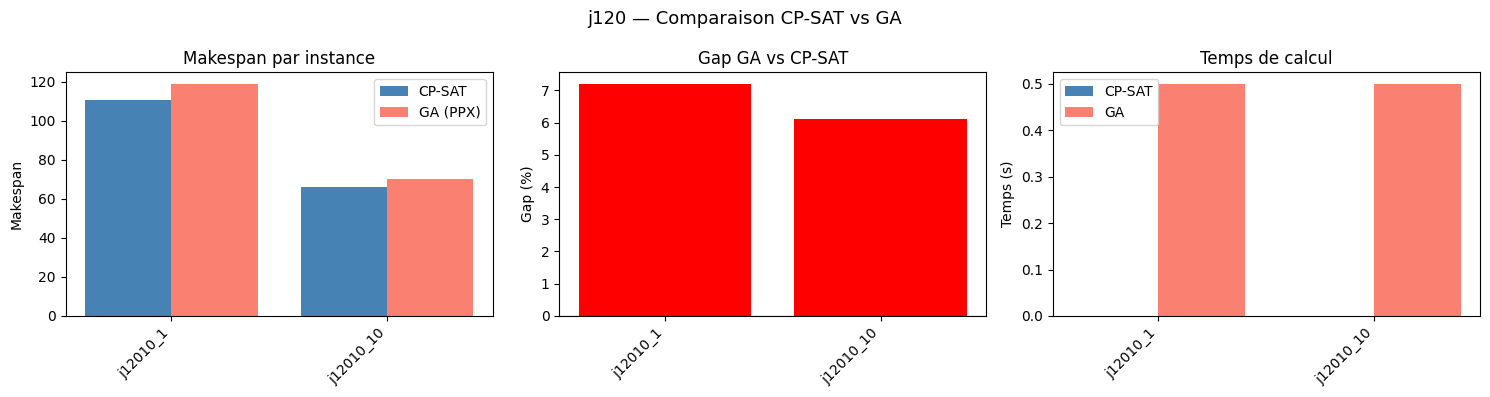

Gap moyen GA/CP-SAT: 6.7% (max: 7.2%)


In [15]:
def plot_benchmark_comparison(results, title):
    if not results:
        print(f'Pas de resultats pour {title}')
        return
    df = pd.DataFrame(results)
    x = list(range(len(df)))
    labels = df['instance'].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Makespan CP-SAT vs GA
    ax = axes[0]
    ax.bar([i - 0.2 for i in x], df['cp_makespan'], 0.4, label='CP-SAT', color='steelblue')
    ax.bar([i + 0.2 for i in x], df['ga_makespan'], 0.4, label='GA (PPX)', color='salmon')
    if df['bks'].notna().any():
        bks_vals = df['bks'].tolist()
        ax.plot(x, bks_vals, 'g^--', label='BKS', markersize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Makespan')
    ax.set_title('Makespan par instance')
    ax.legend()

    # Gap GA vs CP-SAT (%)
    ax = axes[1]
    gaps = df['gap_ga_pct'].fillna(0).tolist()
    colors = ['green' if g == 0 else 'orange' if g < 5 else 'red' for g in gaps]
    ax.bar(x, gaps, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Gap (%)')
    ax.set_title('Gap GA vs CP-SAT')
    ax.axhline(0, color='black', linewidth=0.8)

    # Temps de calcul
    ax = axes[2]
    ax.bar([i - 0.2 for i in x], df['cp_time_s'], 0.4, label='CP-SAT', color='steelblue')
    ax.bar([i + 0.2 for i in x], df['ga_time_s'], 0.4, label='GA', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Temps (s)')
    ax.set_title('Temps de calcul')
    ax.legend()

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

    valid = df[df['gap_ga_pct'].notna()]
    if not valid.empty:
        print(f"Gap moyen GA/CP-SAT: {valid['gap_ga_pct'].mean():.1f}% "
              f"(max: {valid['gap_ga_pct'].max():.1f}%)")


plot_benchmark_comparison(results_j30, 'j30 — Comparaison CP-SAT vs GA')
plot_benchmark_comparison(results_j60, 'j60 — Comparaison CP-SAT vs GA')
plot_benchmark_comparison(results_j120, 'j120 — Comparaison CP-SAT vs GA')


## 8. Stratégies de branchement CP-SAT

CP-SAT propose plusieurs stratégies de branchement configurables via `solver.parameters.search_branching` :

- `0` **Automatique** (portfolio interne, défaut)
- `3` **Portfolio** (combinaison heuristiques)
- `4` **LP-based** (basé sur la relaxation LP, *activity-based*)
- `5` **PseudoCost** (analogue à VSIDS/EVSIDS)
- `6` **Portfolio+Restart** (portfolio avec redémarrages rapides)

On compare ces stratégies sur 3 instances j30 avec un budget de 10s.


--- j3010_1 ---
  Automatique           : makespan=42 (OPTIMAL) branches=0 conflits=0 t=0.01s
  Portfolio             : makespan=42 (OPTIMAL) branches=17 conflits=0 t=0.01s
  LP (activity-based)   : makespan=42 (OPTIMAL) branches=1 conflits=1 t=0.01s
  PseudoCost (VSIDS)    : makespan=42 (OPTIMAL) branches=54 conflits=1 t=0.01s
  Portfolio+Restart     : makespan=42 (OPTIMAL) branches=48 conflits=0 t=0.01s

--- j3010_10 ---
  Automatique           : makespan=41 (OPTIMAL) branches=0 conflits=0 t=0.01s
  Portfolio             : makespan=41 (OPTIMAL) branches=0 conflits=0 t=0.01s
  LP (activity-based)   : makespan=41 (OPTIMAL) branches=0 conflits=0 t=0.01s
  PseudoCost (VSIDS)    : makespan=41 (OPTIMAL) branches=0 conflits=0 t=0.01s
  Portfolio+Restart     : makespan=41 (OPTIMAL) branches=0 conflits=0 t=0.01s

--- j3010_2 ---
  Automatique           : makespan=56 (OPTIMAL) branches=0 conflits=0 t=0.01s
  Portfolio             : makespan=56 (OPTIMAL) branches=0 conflits=0 t=0.01s
  LP (act

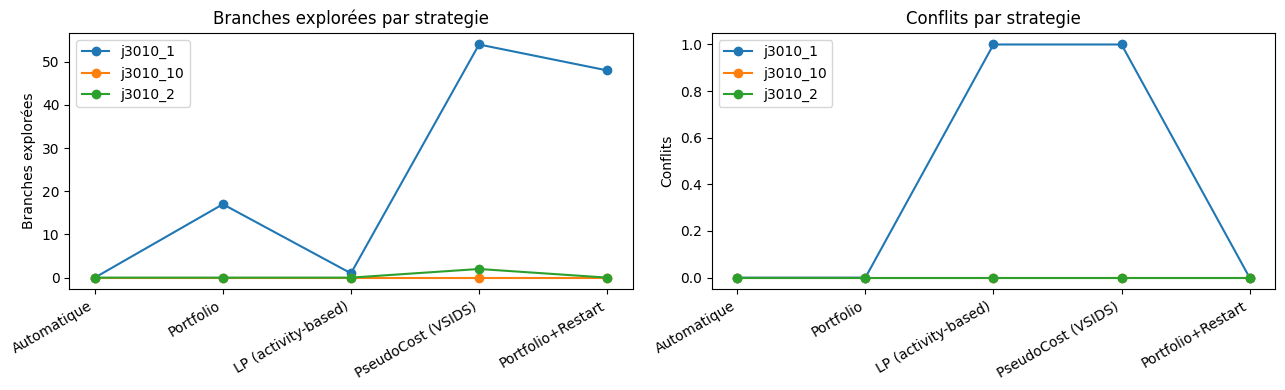

In [16]:
# Les constantes enum sont recuperees depuis le wrapper C++ de CP-SAT
_sp = cp_model.CpSolver().parameters

BRANCHING_STRATEGIES = {
    'Automatique':          _sp.AUTOMATIC_SEARCH,
    'Portfolio':            _sp.PORTFOLIO_SEARCH,
    'LP (activity-based)':  _sp.LP_SEARCH,
    'PseudoCost (VSIDS)':   _sp.PSEUDO_COST_SEARCH,
    'Portfolio+Restart':    _sp.PORTFOLIO_WITH_QUICK_RESTART_SEARCH,
}


def solve_rcpsp_with_branching(parsed_data, branching, max_time=10):
    model = cp_model.CpModel()
    jobs = parsed_data['jobs']
    horizon = parsed_data['horizon']
    durations = parsed_data['durations']
    requests = parsed_data['requests']
    capacities = parsed_data['capacities']
    num_renewable = parsed_data['num_renewable']

    tasks, starts, ends = {}, {}, {}
    for j in range(1, jobs + 1):
        starts[j] = model.NewIntVar(0, horizon, f's{j}')
        ends[j] = model.NewIntVar(0, horizon, f'e{j}')
        tasks[j] = model.NewIntervalVar(starts[j], durations[j], ends[j], f't{j}')

    for j, succs in parsed_data['precedences'].items():
        for s in succs:
            model.Add(starts[s] >= ends[j])

    for r in range(num_renewable):
        ivs = [tasks[j] for j in range(1, jobs+1) if requests[j][r] > 0]
        dems = [requests[j][r] for j in range(1, jobs+1) if requests[j][r] > 0]
        model.AddCumulative(ivs, dems, capacities[r])

    mk = model.NewIntVar(0, horizon, 'mk')
    model.Add(mk == ends[jobs])
    model.Minimize(mk)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_time
    solver.parameters.search_branching = branching

    t0 = time.time()
    status = solver.Solve(model)
    elapsed = round(time.time() - t0, 2)

    return {
        'makespan': int(solver.ObjectiveValue()) if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None,
        'status': solver.StatusName(status),
        'time_s': elapsed,
        'num_branches': solver.NumBranches(),
        'num_conflicts': solver.NumConflicts(),
    }


branching_files = sorted(glob.glob('data/j30/*.sm'))[:3]
branching_rows = []

for fpath in branching_files:
    name = os.path.basename(fpath).replace('.sm', '')
    data = parse_sm_file(fpath)
    print(f'\n--- {name} ---')
    for strat_name, strat_id in BRANCHING_STRATEGIES.items():
        r = solve_rcpsp_with_branching(data, strat_id, max_time=10)
        branching_rows.append({'instance': name, 'strategie': strat_name, **r})
        print(f'  {strat_name:<22}: makespan={r["makespan"]} ({r["status"]}) '
              f'branches={r["num_branches"]:,} conflits={r["num_conflicts"]:,} '
              f't={r["time_s"]}s')

df_branch = pd.DataFrame(branching_rows)

# Graphe: nombre de branches par strategie
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, label in [
    (axes[0], 'num_branches', 'Branches explorées'),
    (axes[1], 'num_conflicts', 'Conflits'),
]:
    for inst in df_branch['instance'].unique():
        sub = df_branch[df_branch['instance'] == inst]
        ax.plot(sub['strategie'], sub[metric], marker='o', label=inst)
    ax.set_ylabel(label)
    ax.set_title(label + ' par strategie')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 9. Variante RCPSP/max (décalages temporels généralisés)

RCPSP/max généralise les contraintes de précédence avec des *décalages temporels* :

$$\text{start}[j] - \text{start}[i] \geq \delta_{ij}$$

- **Précédence standard** : $\delta_{ij} = \text{dur}[i]$ → $\text{start}[j] \geq \text{end}[i]$
- **Lag positif** : délai minimum entre le début de $i$ et le début de $j$
- **Lag négatif** : chevauchement autorisé ($j$ peut commencer avant la fin de $i$)

Le modèle CP-SAT ajoute simplement `model.Add(starts[j] - starts[i] >= delta)`.

Standard  : makespan=14 (OPTIMAL)
RCPSP/max : makespan=14 (OPTIMAL)
Gain du lag negatif : 0 unites


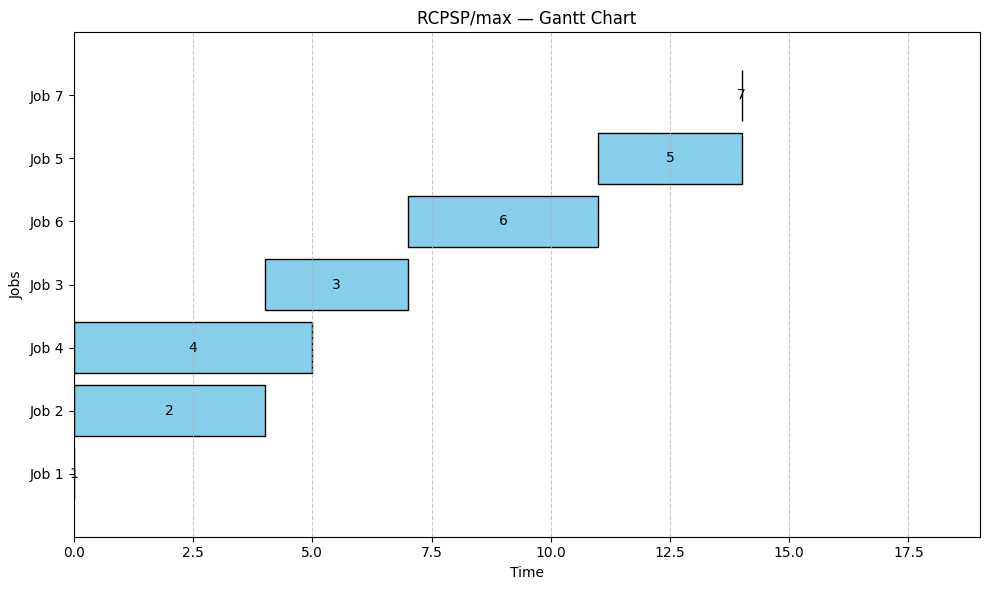

In [17]:
def solve_rcpsp_max(num_jobs, durations, temporal_constraints, requests, capacities,
                    horizon=None, max_time=30):
    """
    RCPSP/max: temporal_constraints = liste de (i, j, delta)
    Contrainte: start[j] - start[i] >= delta
    """
    model = cp_model.CpModel()
    if horizon is None:
        horizon = sum(durations.values()) * 2
    num_r = len(capacities)

    starts = {j: model.NewIntVar(0, horizon, f's{j}') for j in range(1, num_jobs+1)}
    ends   = {j: model.NewIntVar(0, horizon, f'e{j}') for j in range(1, num_jobs+1)}
    tasks  = {
        j: model.NewIntervalVar(starts[j], durations[j], ends[j], f't{j}')
        for j in range(1, num_jobs+1)
    }

    for (i, j, delta) in temporal_constraints:
        model.Add(starts[j] - starts[i] >= delta)

    for r in range(num_r):
        ivs  = [tasks[j]      for j in range(1, num_jobs+1) if requests[j][r] > 0]
        dems = [requests[j][r] for j in range(1, num_jobs+1) if requests[j][r] > 0]
        if ivs:
            model.AddCumulative(ivs, dems, capacities[r])

    mk = model.NewIntVar(0, horizon, 'mk')
    model.Add(mk == ends[num_jobs])
    model.Minimize(mk)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_time
    status = solver.Solve(model)

    result = {'status': solver.StatusName(status), 'makespan': None, 'schedule': {}}
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        result['makespan'] = int(solver.ObjectiveValue())
        for j in range(1, num_jobs+1):
            result['schedule'][j] = {
                'start': solver.Value(starts[j]),
                'end':   solver.Value(ends[j])
            }
    return result


# Instance synthetique RCPSP/max (7 taches + supersource 1 + supersink 7)
# Ressource: 1 ressource renouvelable, capacite 8
rcpmax_jobs = 7
rcpmax_dur  = {1: 0, 2: 4, 3: 3, 4: 5, 5: 3, 6: 4, 7: 0}
rcpmax_req  = {1: [0], 2: [5], 3: [4], 4: [3], 5: [5], 6: [4], 7: [0]}
rcpmax_cap  = [8]

# Contraintes temporelles
# (i, j, delta) : start[j] >= start[i] + delta
rcpmax_tc = [
    (1, 2, 0), (1, 3, 0), (1, 4, 0),           # supersource -> taches reelles
    (2, 5, rcpmax_dur[2]),                       # precedence standard: 5 apres fin de 2
    (3, 5, rcpmax_dur[3]),                       # precedence standard: 5 apres fin de 3
    (3, 6, rcpmax_dur[3]),                       # precedence standard: 6 apres fin de 3
    (4, 6, rcpmax_dur[4]),                       # precedence standard: 6 apres fin de 4
    (5, 7, rcpmax_dur[5]),                       # vers supersink
    (6, 7, rcpmax_dur[6]),                       # vers supersink
    (2, 3, -2),                                  # RCPSP/max: start[3] >= start[2] - 2
    #  => tache 3 peut commencer jusqu'a 2 unites AVANT tache 2
]

# Comparaison RCPSP standard vs RCPSP/max (avec lag negatif)
# Standard: remplace le lag negatif par la precedence stricte start[3] >= start[2]
rcpmax_tc_std = [tc for tc in rcpmax_tc if not (tc[0] == 2 and tc[1] == 3)] + [(2, 3, 0)]

res_std  = solve_rcpsp_max(rcpmax_jobs, rcpmax_dur, rcpmax_tc_std, rcpmax_req, rcpmax_cap)
res_max  = solve_rcpsp_max(rcpmax_jobs, rcpmax_dur, rcpmax_tc,     rcpmax_req, rcpmax_cap)

print(f'Standard  : makespan={res_std["makespan"]} ({res_std["status"]})')
print(f'RCPSP/max : makespan={res_max["makespan"]} ({res_max["status"]})')
print(f'Gain du lag negatif : {res_std["makespan"] - res_max["makespan"]} unites')

if res_max['schedule']:
    plot_gantt_chart(res_max['schedule'], 'RCPSP/max — Gantt Chart')


## 10. RCPSP multi-mode

Dans le RCPSP multi-mode, chaque tâche $j$ dispose de $M_j$ modes d'exécution, chacun avec une durée et des besoins en ressources différents. Le modèle CP-SAT utilise des **intervalles optionnels** : un `BoolVar` par mode, avec exactement un mode actif par tâche.

```
# Par tache j, mode k :
interval = model.NewOptionalIntervalVar(start[j], dur[j][k], end[j], mode_var[j][k])
model.AddExactlyOne(mode_var[j])   # un seul mode actif
```

Multi-mode Status: OPTIMAL, Makespan: 8
Modes choisis:
  Tache 2: mode 0 (duree=3, ressource=4)
  Tache 3: mode 1 (duree=4, ressource=1)
  Tache 4: mode 0 (duree=4, ressource=3)
  Tache 5: mode 1 (duree=3, ressource=3)


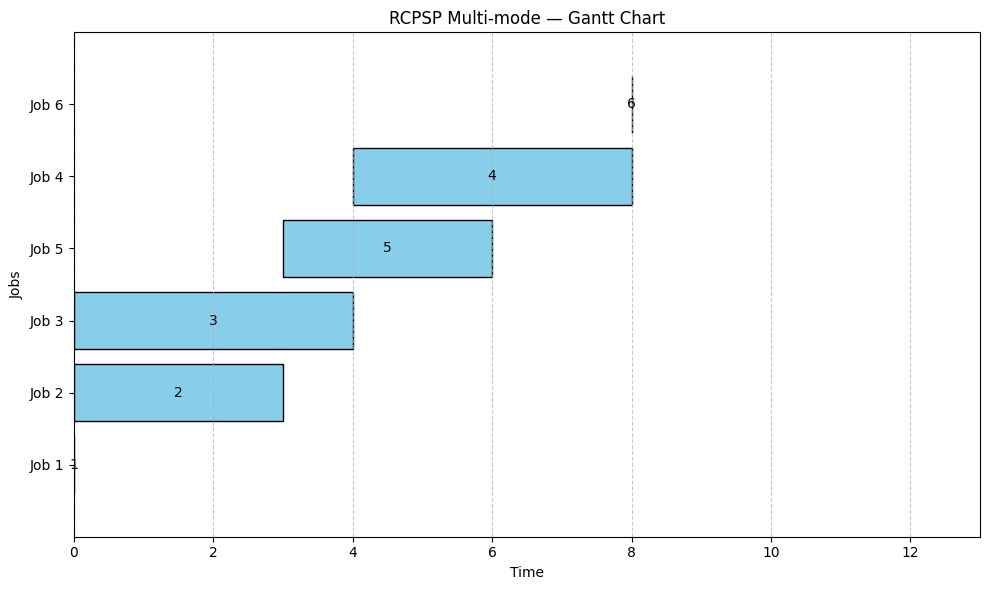

In [18]:
def solve_rcpsp_multimode(num_jobs, precedences, modes, capacities,
                          horizon=None, max_time=30):
    """
    RCPSP multi-mode.
    modes: dict job -> list of (duration, [req_r1, req_r2, ...])
    """
    model = cp_model.CpModel()
    num_r = len(capacities)
    if horizon is None:
        horizon = sum(max(m[0] for m in modes[j]) for j in range(1, num_jobs+1))

    starts = {j: model.NewIntVar(0, horizon, f's{j}') for j in range(1, num_jobs+1)}
    ends   = {j: model.NewIntVar(0, horizon, f'e{j}') for j in range(1, num_jobs+1)}
    selected_mode = {}  # job -> liste de BoolVar (un par mode)

    resource_intervals = [[] for _ in range(num_r)]
    resource_demands   = [[] for _ in range(num_r)]

    for j in range(1, num_jobs+1):
        job_modes = modes[j]
        mvars = [model.NewBoolVar(f'm{j}_{k}') for k in range(len(job_modes))]
        model.AddExactlyOne(mvars)
        selected_mode[j] = mvars

        for k, (dur, reqs) in enumerate(job_modes):
            # Intervalle actif seulement si le mode k est selectionne
            iv = model.NewOptionalIntervalVar(
                starts[j], dur, ends[j], mvars[k], f'iv{j}_{k}'
            )
            for r in range(num_r):
                if reqs[r] > 0:
                    resource_intervals[r].append(iv)
                    resource_demands[r].append(reqs[r])

    for j, succs in precedences.items():
        for s in succs:
            model.Add(starts[s] >= ends[j])

    for r in range(num_r):
        if resource_intervals[r]:
            model.AddCumulative(resource_intervals[r], resource_demands[r], capacities[r])

    mk = model.NewIntVar(0, horizon, 'mk')
    model.Add(mk == ends[num_jobs])
    model.Minimize(mk)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_time
    status = solver.Solve(model)

    result = {'status': solver.StatusName(status), 'makespan': None,
              'schedule': {}, 'modes_chosen': {}}
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        result['makespan'] = int(solver.ObjectiveValue())
        for j in range(1, num_jobs+1):
            result['schedule'][j] = {
                'start': solver.Value(starts[j]),
                'end':   solver.Value(ends[j])
            }
            for k, mv in enumerate(selected_mode[j]):
                if solver.BooleanValue(mv):
                    result['modes_chosen'][j] = k
    return result


# Instance synthetique multi-mode
# 6 taches (source=1, sink=6), 1 ressource renouvelable cap=6
# Chaque tache: modes (duree, [besoin_ressource])
# Mode rapide = duree courte mais forte demande ressource
# Mode lent   = duree longue mais faible demande ressource
mm_jobs = 6
mm_prec = {1: [2, 3], 2: [4, 5], 3: [4], 4: [6], 5: [6], 6: []}
mm_cap  = [6]
mm_modes = {
    1: [(0, [0])],                # supersource: 1 seul mode, duree 0
    2: [(3, [4]), (5, [2])],      # rapide: 3j/4u vs lent: 5j/2u
    3: [(2, [3]), (4, [1])],
    4: [(4, [3]), (7, [2])],
    5: [(2, [5]), (3, [3])],
    6: [(0, [0])],                # supersink
}

res_mm = solve_rcpsp_multimode(mm_jobs, mm_prec, mm_modes, mm_cap)
print(f'Multi-mode Status: {res_mm["status"]}, Makespan: {res_mm["makespan"]}')

if res_mm['schedule']:
    print('Modes choisis:')
    for j in range(2, mm_jobs):  # exclure source/sink
        k = res_mm['modes_chosen'].get(j, '?')
        dur, reqs = mm_modes[j][k]
        print(f'  Tache {j}: mode {k} (duree={dur}, ressource={reqs[0]})')
    plot_gantt_chart(res_mm['schedule'], 'RCPSP Multi-mode — Gantt Chart')
